# UNI2 原理·玩具版：不看标签，模型怎么学会"看"病理 patch？

> 这个 notebook 只回答一个问题：**特征提取器（UNI2 这类病理基础模型）不借助任何人工标签，是怎么学会提取好特征的？**
>
> 📚 玩具版系列第二篇。第一篇 [CLAM_原理_玩具版.ipynb](CLAM_原理_玩具版.ipynb) 讲的是"有了特征之后怎么用注意力分类"；
> 本篇往前退一步：**特征本身是哪来的**。姊妹篇：[CONCH](CONCH_原理_玩具版.ipynb)（图文对齐）、[TITAN](TITAN_原理_玩具版.ipynb)（切片级基础模型）。

**背景**：主流程第 3 步用的 ResNet50 是在 1400 万张自然图片（猫、狗、汽车）上学的——病理图像不是它的"母语"。
UNI / UNI2 的思路：拿**几亿张病理 patch**，不看任何诊断标签，让模型自己总结出"什么才是病理图像里重要的东西"。

**你将看到**（本场实验的戏剧冲突是病理界最臭名昭著的**批次效应**）：
1. 造一个"3 种组织 × 3 台扫描仪"的假世界
2. 原始特征在"随机划分"考试里成绩很好，在"换台扫描仪"考试里直接崩盘
3. 不看标签的对比学习如何把这个问题修好

## 1. 问题设定：3 种组织 × 3 台扫描仪

- **3 种组织类型**（上皮 / 间质 / 坏死）：各有自己的"原型长相"（4 维向量，靠得比较近——真实组织形态就是渐变的）
- **3 台扫描仪**：每台有强烈的整体"色调偏移"（不同医院、不同品牌的真实差异）。偏移之大，**远超组织之间的差别**——这是关键设定

每个 patch 被两台**随机**扫描仪各"扫"一次，得到两个观测（= 数据增强的两个版本）。

先记住一个考点：如果考试时训练和测试的切片**来自同样的扫描仪**（随机划分），模型可以偷偷利用色调捷径；
真正严格的考试是**留一扫描仪法**（leave-one-scanner-out）：在 1、2 号机上训练，在从没见过的 3 号机上考试。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42); rng = np.random.default_rng(42)

# ============ 造假世界 ============
N_PATCH, DIM = 900, 4
PROTOS = np.array([[1, 1, 0, 0],      # 上皮
                   [0, 0, 1, 1],      # 间质
                   [1, 0, 0, 1]], dtype=np.float32)   # 坏死（组织间差别小）
SCANNERS = np.array([[ 1,   0,   1,   0  ],           # 1 号机偏色 A
                     [ 0,   1,   0,   1  ],           # 2 号机偏色 B
                     [-0.7, -0.7, 0.7, 0.7]], dtype=np.float32) * 3.5   # 3 号机偏色 C（偏移 >> 组织差别）
CLASS_NAMES = ['上皮', '间质', '坏死']

labels = np.repeat(np.arange(3), N_PATCH // 3)                # 组织类型（隐藏标签，训练绝不用）
content = (PROTOS[labels] + rng.normal(0, 0.25, (N_PATCH, DIM))).astype(np.float32)  # 内容：原型+自然差异

def observe(c):
    """观测一次 = 内容 + 某台扫描仪的偏色 + 测量噪声。返回 (观测值, 用了哪台机)。"""
    s = rng.integers(0, 3, len(c))                             # 随机抽一台扫描仪
    obs = (c + SCANNERS[s] + rng.normal(0, 0.35, (len(c), DIM))).astype(np.float32)
    return obs, s

view1, scan1 = observe(content)     # 同一批 patch 第一次观测
view2, scan2 = observe(content)     # 第二次观测（换了随机扫描仪）

print(f'patch 数: {N_PATCH} | 组织类型: 3 类 | 扫描仪: 3 台')
print('同一个 patch 在两台扫描仪上的观测（前 2 个）:')
for i in range(2):
    print(f'  patch {i} [{CLASS_NAMES[labels[i]]}]: {int(scan1[i])+1} 号机={np.round(view1[i],1)}   {int(scan2[i])+1} 号机={np.round(view2[i],1)}')
print('→ 同一个东西，换台机器数值差了一大截')

patch 数: 900 | 组织类型: 3 类 | 扫描仪: 3 台
同一个 patch 在两台扫描仪上的观测（前 2 个）:
  patch 0 [上皮]: 3 号机=[-1.4 -1.7  2.1  2.3]   2 号机=[ 0.7  4.7 -0.2  3.7]
  patch 1 [上皮]: 1 号机=[ 4.   0.6  3.3 -0.1]   1 号机=[4.  1.  3.7 0.1]
→ 同一个东西，换台机器数值差了一大截


## 2. 原始特征的两场考试：随机划分 vs 换台扫描仪

用 **5-NN 准确率**当考试（看一个 patch 的 5 个最近邻里多少是同类——标签只做考卷，不参与任何训练）：

- **随机划分**：训练和测试里三台扫描仪的图都有 → 可以偷偷依赖"色调捷径"
- **留一扫描仪**：只用 1、2 号机的数据当参考，考 3 号机 → 捷径失效，原形毕露

再把原始特征空间画出来：左图按组织类型着色，右图按扫描仪着色——**看看这个空间到底是按什么组织的**。

随机划分考试:      92.0%   ← 看起来很不错？
留一扫描仪考试:    32.0%   ← 换台机器直接崩盘（瞎猜 = 33%）
这就是批次效应：认的是"扫描仪色调"，不是"组织形态"。


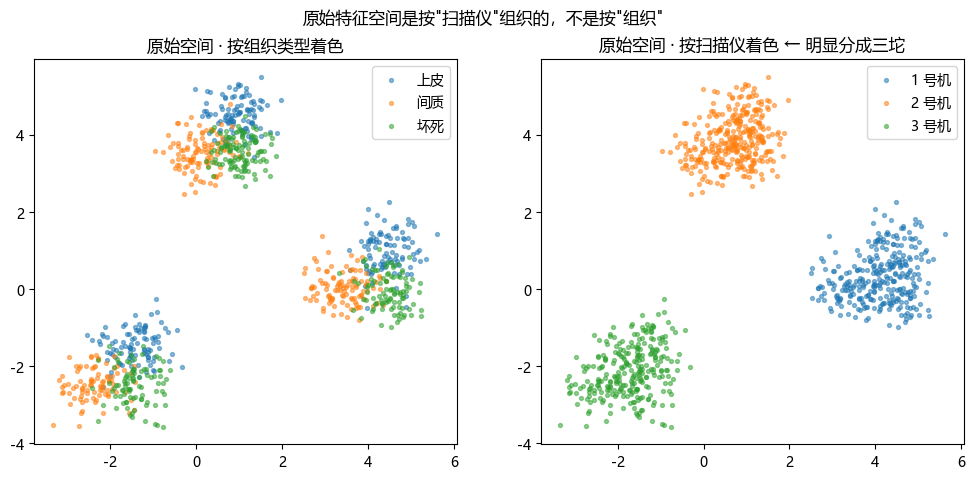

In [2]:
# 考试一：随机划分（三台机的图混在一起切分）
Xtr, Xte, ytr, yte = train_test_split(view1, labels, test_size=1/3, random_state=0, stratify=labels)
acc_random = KNeighborsClassifier(5).fit(Xtr, ytr).score(Xte, yte)

# 考试二：留一扫描仪（只用 1、2 号机当参考，考完全没见过的 3 号机）
seen, unseen = scan1 < 2, scan1 == 2
acc_loso = KNeighborsClassifier(5).fit(view1[seen], labels[seen]).score(view1[unseen], labels[unseen])

print(f'随机划分考试:      {acc_random:.1%}   ← 看起来很不错？')
print(f'留一扫描仪考试:    {acc_loso:.1%}   ← 换台机器直接崩盘（瞎猜 = 33%）')
print('这就是批次效应：认的是"扫描仪色调"，不是"组织形态"。')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for c in range(3):
    m = labels == c
    axes[0].scatter(view1[m, 0], view1[m, 1], s=8, alpha=0.5, label=CLASS_NAMES[c])
for s in range(3):
    m = scan1 == s
    axes[1].scatter(view1[m, 0], view1[m, 1], s=8, alpha=0.5, label=f'{s+1} 号机')
axes[0].set_title('原始空间 · 按组织类型着色'); axes[0].legend()
axes[1].set_title('原始空间 · 按扫描仪着色 ← 明显分成三坨'); axes[1].legend()
plt.suptitle('原始特征空间是按"扫描仪"组织的，不是按"组织"'); plt.show()

## 3. 核心思想："同一个 patch，换台机器扫，特征不应该变"

不看标签怎么学习？靠一条**不证自明的常识**：

> 同一个 patch 在 1 号机和 3 号机上的两次扫描，说的明明是**同一个东西**——特征就应该一样；
> 两个不同的 patch，特征就应该不一样。

逼着模型满足这一条，它就**被迫**学会忽略扫描仪差异（两次观测间唯一不同的东西），只留下"内容"（唯一不变的东西）。
这就是**自监督学习**的灵魂——昂贵的人工标签被"一致性"这个免费信号替代了。

训练目标（对比损失 / InfoNCE）：
```
900 个 patch × 2 次观测 = 1800 个特征
对每个观测：它的"另一半"是正样本（要靠近），其余 1798 个是负样本（要远离）
→ 本质是 1799 选 1 的分类题："茫茫人海中，认出另一个你"
```
（又是 softmax——和 CLAM 玩具版 1.5 节是同一个数学零件，这次用来"给 1799 个候选打分挑一个"。）

In [3]:
enc = nn.Sequential(nn.Linear(DIM, 32), nn.ReLU(), nn.Linear(32, 3))   # 迷你编码器：4 维观测 → 3 维特征
opt = torch.optim.Adam(enc.parameters(), lr=3e-3)
V1, V2 = torch.from_numpy(view1), torch.from_numpy(view2)
TAU = 0.3

for ep in range(3000):
    z = F.normalize(torch.cat([enc(V1), enc(V2)]), dim=1)   # 1800 个特征，归一化到单位球面
    sim = z @ z.T / TAU                                     # 两两相似度 (1800, 1800)
    sim.fill_diagonal_(-1e9)                                # 自己和自己不算
    targets = torch.cat([torch.arange(N_PATCH) + N_PATCH, torch.arange(N_PATCH)])  # 另一半的位置
    loss = F.cross_entropy(sim, targets)                    # 1799 选 1
    opt.zero_grad(); loss.backward(); opt.step()
    if ep % 1000 == 999:
        print(f'epoch {ep+1:4d}: 对比损失 = {loss.item():.3f}  (完全瞎猜 = {np.log(1799):.2f})')
print('训练完成（全程没碰过 labels！）')

epoch 1000: 对比损失 = 6.507  (完全瞎猜 = 7.49)


epoch 2000: 对比损失 = 6.486  (完全瞎猜 = 7.49)


epoch 3000: 对比损失 = 6.561  (完全瞎猜 = 7.49)
训练完成（全程没碰过 labels！）


## 4. 见证时刻：换台扫描仪还崩吗？

现在请出标签**只用于考试**。同样的留一扫描仪考试，学习前 vs 学习后；
再顺手查一下学习后的空间里"扫描仪信息"还剩多少（用扫描仪编号当标签考 5-NN——越低说明机器差异被抹得越干净）。

== 留一扫描仪考试（认组织，越高越好）==
  学习前: 32.0%   学习后: 90.2%   ← 修好了一大半
== 反向考试（认扫描仪，越低越好）==
  学习前: 100.0%   学习后: 58.0%   ← 扫描仪痕迹被抹掉了


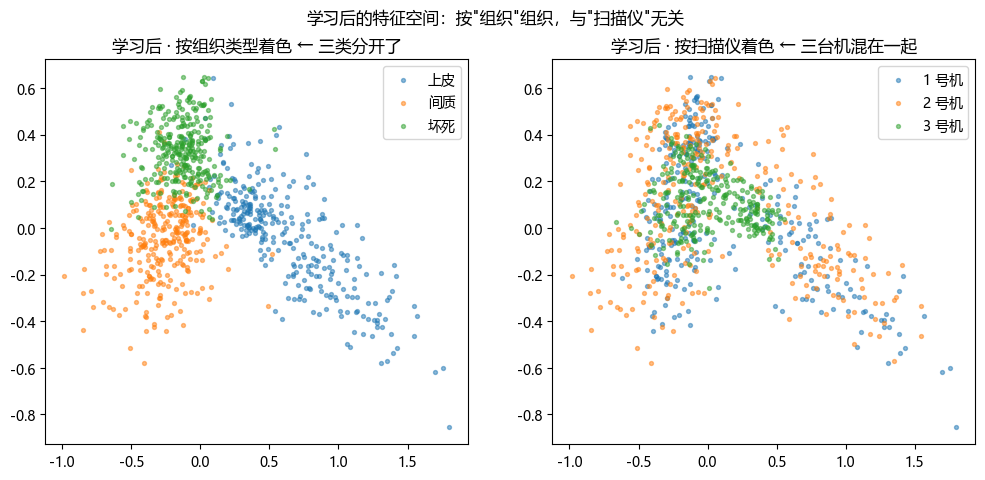

In [4]:
with torch.no_grad():
    feats = enc(V1).numpy()

acc_loso_learned = KNeighborsClassifier(5).fit(feats[seen], labels[seen]).score(feats[unseen], labels[unseen])
# 反向考试用随机划分（留一扫描仪对"认机器"无意义：3 号机的标签根本没在参考库里出现过）
v_tr, v_te, s_tr, s_te = train_test_split(view1, scan1, test_size=1/3, random_state=0, stratify=scan1)
f_tr, f_te, _, _       = train_test_split(feats,  scan1, test_size=1/3, random_state=0, stratify=scan1)
scan_knn_raw     = KNeighborsClassifier(5).fit(v_tr, s_tr).score(v_te, s_te)
scan_knn_learned = KNeighborsClassifier(5).fit(f_tr, s_tr).score(f_te, s_te)

print('== 留一扫描仪考试（认组织，越高越好）==')
print(f'  学习前: {acc_loso:.1%}   学习后: {acc_loso_learned:.1%}   ← 修好了一大半')
print('== 反向考试（认扫描仪，越低越好）==')
print(f'  学习前: {scan_knn_raw:.1%}   学习后: {scan_knn_learned:.1%}   ← 扫描仪痕迹被抹掉了')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for c in range(3):
    m = labels == c
    axes[0].scatter(feats[m, 0], feats[m, 1], s=8, alpha=0.5, label=CLASS_NAMES[c])
for s in range(3):
    m = scan1 == s
    axes[1].scatter(feats[m, 0], feats[m, 1], s=8, alpha=0.5, label=f'{s+1} 号机')
axes[0].set_title('学习后 · 按组织类型着色 ← 三类分开了'); axes[0].legend()
axes[1].set_title('学习后 · 按扫描仪着色 ← 三台机混在一起'); axes[1].legend()
plt.suptitle('学习后的特征空间：按"组织"组织，与"扫描仪"无关'); plt.show()

## 5. 诚实声明：玩具版 vs 真实 UNI2

| | 玩具版（本 notebook） | 真实 UNI2-h |
|---|---|---|
| 学习目标 | 对比学习：认出同一 patch 在两台扫描仪上的观测 | **DINOv2 配方**：老师-学生自蒸馏 + iBOT 遮挡重建 + KoLeo 正则（不用手工配对的正负样本，机制更巧，目标相同：**让"语义相同的 patch"特征靠近**） |
| "增强"是什么 | 换扫描仪 + 加噪声 | 裁剪 / 翻转 / 色彩抖动 / 遮挡 等 |
| 模型 | 2 层 MLP（约 200 个参数） | **ViT-H/14，6.81 亿参数**，24 层 Transformer |
| 输出维度 | 3 维（为了画给你看） | **1536 维**（UNI 一代是 ViT-L/16，1024 维） |
| 训练数据 | 900 个假 patch | **2 亿+张病理 patch**，来自 ~35 万张真实切片（Mass General Brigham，20+ 种器官，H&E + IHC——天然包含海量真实批次效应） |
| 标签 | 完全不用 | 完全不用 |

**在 CLAM 流水线里的位置**：UNI2 是第 3 步特征提取器的"升级版"——把 ResNet50（ImageNet 通用特征，1024 维）换成 UNI2（病理专用特征，1536 维），
下游 CLAM 训练时 `--embed_dim` 改成 1536 即可。病理基础模型对批次效应的抵抗力和小数据表现，通常明显好过 ImageNet 特征。

> ⚖️ 诚实的简化：真实 DINOv2 不做显式的正负样本配对，而是用"老师网络（动量平均）和学生网络看同一图的不同增强，输出分布要一致"+"遮住一部分 patch 重建"来达成同样的不变性。
> 玩具版用对比学习演示同一个思想，因为它最直观。

## 6. 三句话小结

1. **随机划分的好成绩会骗人**：批次效应下，模型可能在学"认医院"而不是"认组织"——留一扫描仪（或留一医院）考试才能试出真本事。
2. **无标签也能学**："同一 patch 的不同增强版本，特征要一致"——这条免费常识足以把特征空间整理成按语义组织、与采集条件无关。
3. **UNI2 就是这个思想 ×（2 亿病理 patch + 6.8 亿参数）**：训练一次，全网免费用，当下游所有任务的特征提取器。

→ 下一篇 [CONCH_原理_玩具版.ipynb](CONCH_原理_玩具版.ipynb)：如果训练数据不是"标签"，而是"图文配对"，模型能学会什么？（剧透：按文字描述找图、零样本分类）